**single_point_mutations.tsv**: contains only single point mutations (2531 rows)

**1temp.tsv**: contains all ProThermDB entries w/ $\Delta\Delta G$ values (3949 rows, not included in repo but potential future addition)

In [1]:
# ! pip install xgboost

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

In [3]:
from xgboost import XGBRegressor

## 1. Filter ProTherm for single point mutations
Some of the structures include mutation information relative to the UniProt ID (e.g. D44N), while some have a PDB ID for the WT and mutant proteins. I'll extract these columns (along with the $\Delta\Delta G$ values) and figure out which mutants have which type of information.

In [4]:
file = 'single_point_mutations.tsv'
table = pd.read_csv(file, sep='\t')

table.head()

,NO,PROTEIN,UniProt_ID,MUTATION,SOURCE,PDB_wild,PDB_Chain_Mutation,SEC_STR,ASA,pH,T_(C),∆∆G_(kcal/mol),∆∆G_H2O_(kcal/mol),STATE,REVERSIBILITY,PubMed_ID,KEY_WORDS,REFERENCE,AUTHOR
0,176,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.73,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
1,177,Villin-1,P02640,E795Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.9,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
2,178,Villin-1,P02640,D796N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.61,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
3,179,Villin-1,P02640,E822Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,-,1.6,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"
4,181,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,6.0,-,-0.46,-,-,-,33779182.0,Ferritin; nativs-side chain;Xa,"J Phys Chem B 125, 3269-3277 (2021) PMID: 3377...","Zou J, Xiao S, Simmerling C, Raleigh DP"


In [5]:
# remove unnecessary columns for now
table = table.iloc[:, [1, 2, 3, 4, 5, 6, 9, 11]]

In [6]:
# keep only structures that have either a UniProt or PDB mutation
table['TYPE'] = ['PDB' if 'PDB' in x else 'UniProt' if 'UniProt' in x else 'Unknown' for x in table['MUTATION']]
table = table[table['TYPE'] != 'Unknown']

In [7]:
table.dropna(subset=['∆∆G_(kcal/mol)'], inplace=True)

In [8]:
table.head()  # final table

,PROTEIN,UniProt_ID,MUTATION,SOURCE,PDB_wild,PDB_Chain_Mutation,pH,∆∆G_(kcal/mol),TYPE
0,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.73,UniProt
1,Villin-1,P02640,E795Q (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.9,UniProt
2,Villin-1,P02640,D796N (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.61,UniProt
3,Villin-1,P02640,E822Q (UniProt),Gallus gallus (Chicken),1YRF,-,3.0,1.6,UniProt
4,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,6.0,-0.46,UniProt


In [9]:
table.shape  # dimensions after filtering

(2320, 9)

In [10]:
table_uniprot = table[table['TYPE'] == 'UniProt']
table_pdb = table[table['TYPE'] == 'PDB']

In [11]:
table_uniprot.shape

(511, 9)

In [12]:
table_pdb.shape

(1809, 9)

## 2. Baseline Model

### 2.A Preprocess data for XGBoost

In [13]:
# https://www.genome.jp/entry/aaindex:ARGP820101 hydrophobicity
# https://www.genome.jp/entry/aaindex:KLEP840101 net charge
# https://www.genome.jp/entry/aaindex:FASG760101 weight
aa_properties = {
    'A': {'hydrophobicity': 0.61, 'charge': 0, 'weight': 89.09},
    'R': {'hydrophobicity': 0.60, 'charge': 1, 'weight': 174.20},
    'N': {'hydrophobicity': 0.06, 'charge': 0, 'weight': 132.12},
    'D': {'hydrophobicity': 0.46, 'charge': -1, 'weight': 133.10},
    'C': {'hydrophobicity': 1.07, 'charge': 0, 'weight': 121.15},
    'Q': {'hydrophobicity': 0., 'charge': 0, 'weight': 146.15},
    'E': {'hydrophobicity': 0.47, 'charge': -1, 'weight': 147.13},
    'G': {'hydrophobicity': 0.07, 'charge': 0, 'weight': 75.07},
    'H': {'hydrophobicity': 0.61, 'charge': 0, 'weight': 155.16},
    'I': {'hydrophobicity': 2.22, 'charge': 0, 'weight': 131.17},
    'L': {'hydrophobicity': 1.53, 'charge': 0, 'weight': 131.17},
    'K': {'hydrophobicity': 1.15, 'charge': 1, 'weight': 146.19},
    'M': {'hydrophobicity': 1.18, 'charge': 0, 'weight': 149.21},
    'F': {'hydrophobicity': 2.02, 'charge': 0, 'weight': 165.19},
    'P': {'hydrophobicity': 1.95, 'charge': 0, 'weight': 115.13},
    'S': {'hydrophobicity': 0.05, 'charge': 0, 'weight': 105.09},
    'T': {'hydrophobicity': 0.05, 'charge': 0, 'weight': 119.12},
    'W': {'hydrophobicity': 2.65, 'charge': 0, 'weight': 204.24},
    'Y': {'hydrophobicity': 1.88, 'charge': 0, 'weight': 181.19},
    'V': {'hydrophobicity': 1.32, 'charge': 0, 'weight': 117.15}
}

In [14]:
# work with only UniProt mutations for now
table_uniprot_xgb = table_uniprot.copy()  # don't touch original table
table_uniprot_xgb['WT_AA'] = table_uniprot_xgb['MUTATION'].apply(lambda x: x.split()[0][0])
table_uniprot_xgb['MUT_AA'] = table_uniprot_xgb['MUTATION'].apply(lambda x: x.split()[0][-1])
table_uniprot_xgb['POSITION'] = table_uniprot_xgb['MUTATION'].apply(lambda x: int(x.split()[0][1:-1]))

In [15]:
# drop some unnecessary columns 
table_uniprot_xgb.drop(columns=['MUTATION', 'TYPE', 'PDB_Chain_Mutation'], inplace=True)

In [16]:
table_uniprot_xgb.head()

,PROTEIN,UniProt_ID,SOURCE,PDB_wild,pH,∆∆G_(kcal/mol),WT_AA,MUT_AA,POSITION
0,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.73,D,N,44
1,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.9,E,Q,795
2,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.61,D,N,796
3,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.6,E,Q,822
4,Villin-1,P02640,Gallus gallus (Chicken),1YRF,6.0,-0.46,D,N,44


In [17]:
# calculate changes in hydrophobicity, charge, and weight for each mutation
table_uniprot_xgb['delta_hydrophobicity'] = table_uniprot_xgb.apply(lambda row: aa_properties[row['MUT_AA']]['hydrophobicity'] - aa_properties[row['WT_AA']]['hydrophobicity'], axis=1)
table_uniprot_xgb['delta_charge'] = table_uniprot_xgb.apply(lambda row: aa_properties[row['MUT_AA']]['charge'] - aa_properties[row['WT_AA']]['charge'], axis=1)
table_uniprot_xgb['delta_weight'] = table_uniprot_xgb.apply(lambda row: aa_properties[row['MUT_AA']]['weight'] - aa_properties[row['WT_AA']]['weight'], axis=1)

In [18]:
table_uniprot_xgb['∆∆G_(kcal/mol)'].dtype  # strings - need to convert
# TODO: address this when filtering the table above when working with GNN

<StringDtype(storage='python', na_value=nan)>

In [19]:
table_uniprot_xgb['∆∆G_(kcal/mol)'].apply(lambda x: pd.to_numeric(x, errors='coerce')).isnull().sum()  # 15 NaNs (can throw out)

15

In [20]:
table_uniprot_xgb['∆∆G_(kcal/mol)'] = pd.to_numeric(table_uniprot_xgb['∆∆G_(kcal/mol)'], errors='coerce')
table_uniprot_xgb.dropna(subset=['∆∆G_(kcal/mol)'], inplace=True)

In [21]:
table_uniprot_xgb.shape

(496, 12)

In [22]:
# split WT_AA and MUT_AA into separate columns for one-hot encoding
one_hot_wt = pd.get_dummies(table_uniprot_xgb['WT_AA'], prefix='WT')
one_hot_mut = pd.get_dummies(table_uniprot_xgb['MUT_AA'], prefix='MUT')

In [23]:
table_uniprot_xgb = pd.concat([table_uniprot_xgb, one_hot_wt, one_hot_mut], axis=1)

In [24]:
table_uniprot_xgb.head()  # final XGBoost table

,PROTEIN,UniProt_ID,SOURCE,PDB_wild,pH,∆∆G_(kcal/mol),WT_AA,MUT_AA,POSITION,delta_hydrophobicity,...,MUT_M,MUT_N,MUT_P,MUT_Q,MUT_R,MUT_S,MUT_T,MUT_V,MUT_W,MUT_Y
0,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.73,D,N,44,-0.40,...,False,True,False,False,False,False,False,False,False,False
1,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.90,E,Q,795,-0.47,...,False,False,False,True,False,False,False,False,False,False
2,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.61,D,N,796,-0.40,...,False,True,False,False,False,False,False,False,False,False
3,Villin-1,P02640,Gallus gallus (Chicken),1YRF,3.0,1.60,E,Q,822,-0.47,...,False,False,False,True,False,False,False,False,False,False
4,Villin-1,P02640,Gallus gallus (Chicken),1YRF,6.0,-0.46,D,N,44,-0.40,...,False,True,False,False,False,False,False,False,False,False


### 2.B plots to visualize preprocessed data

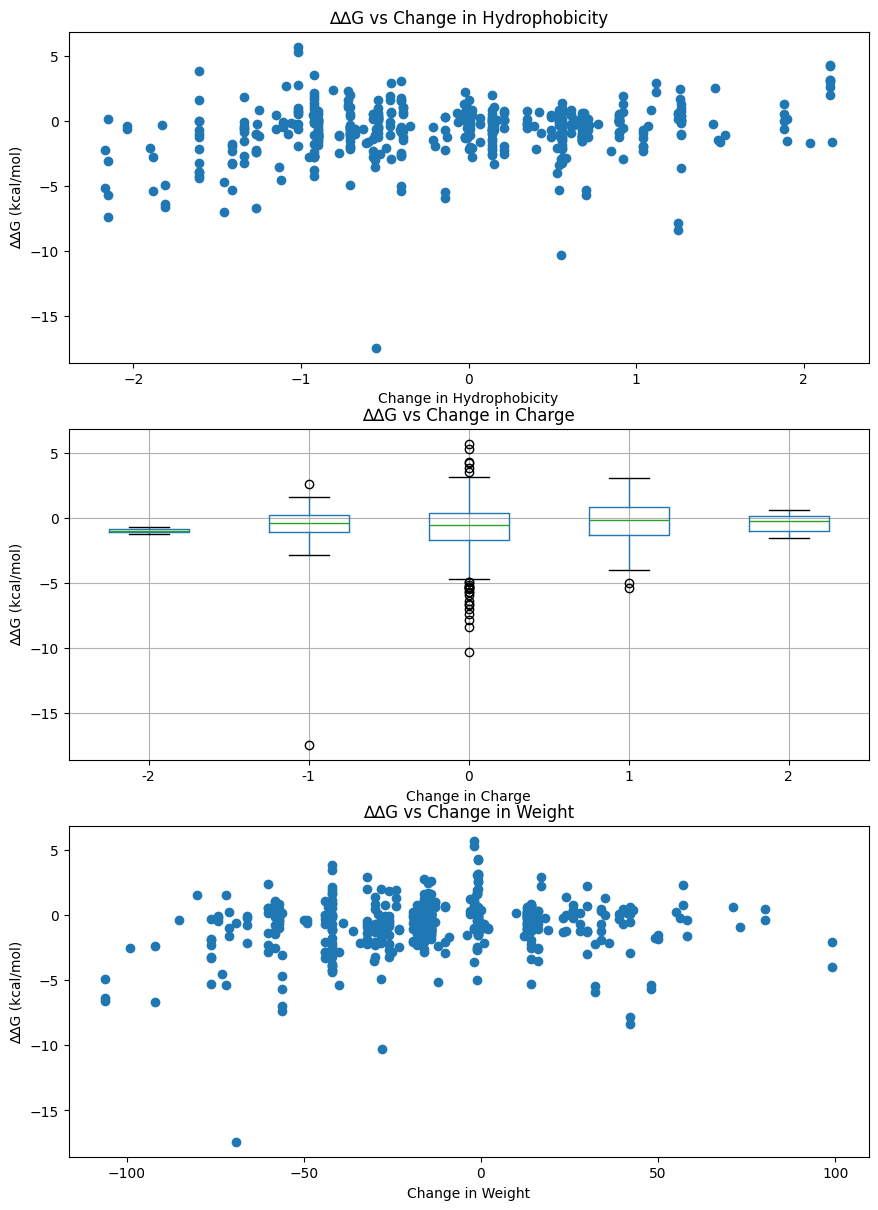

In [25]:
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

ax[0].scatter(table_uniprot_xgb['delta_hydrophobicity'], table_uniprot_xgb['∆∆G_(kcal/mol)'])
ax[0].set_xlabel('Change in Hydrophobicity')
ax[0].set_ylabel('∆∆G (kcal/mol)')
ax[0].set_title('∆∆G vs Change in Hydrophobicity')

table_uniprot_xgb.boxplot(column='∆∆G_(kcal/mol)', by='delta_charge', ax=ax[1])
plt.suptitle('')  # remove default title
ax[1].set_xlabel('Change in Charge')
ax[1].set_ylabel('∆∆G (kcal/mol)')
ax[1].set_title('∆∆G vs Change in Charge')

ax[2].scatter(table_uniprot_xgb['delta_weight'], table_uniprot_xgb['∆∆G_(kcal/mol)'])
ax[2].set_xlabel('Change in Weight')
ax[2].set_ylabel('∆∆G (kcal/mol)')
ax[2].set_title('∆∆G vs Change in Weight')

plt.show()

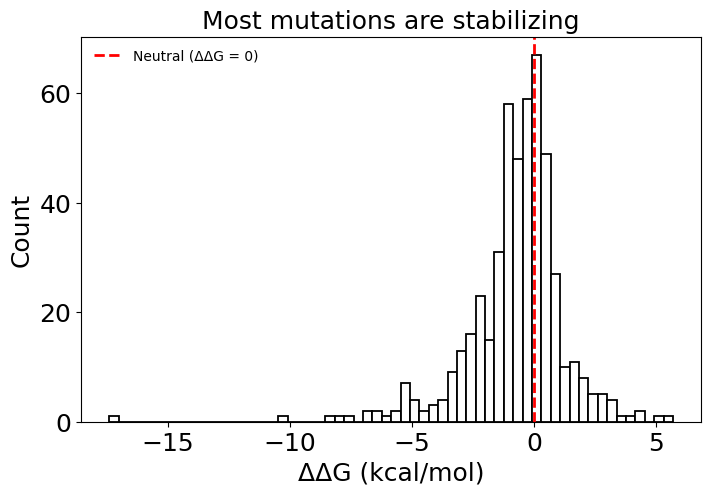

In [26]:
# distribution of ddG (show if most mutations are stabilizing or destabilizing)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(table_uniprot_xgb['∆∆G_(kcal/mol)'], bins=60, edgecolor='black', linewidth=1.3, color='white')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral (ΔΔG = 0)')
ax.set_xlabel('ΔΔG (kcal/mol)', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.set_title('Most mutations are stabilizing', fontsize=18)
ax.legend(frameon=False)
plt.show()

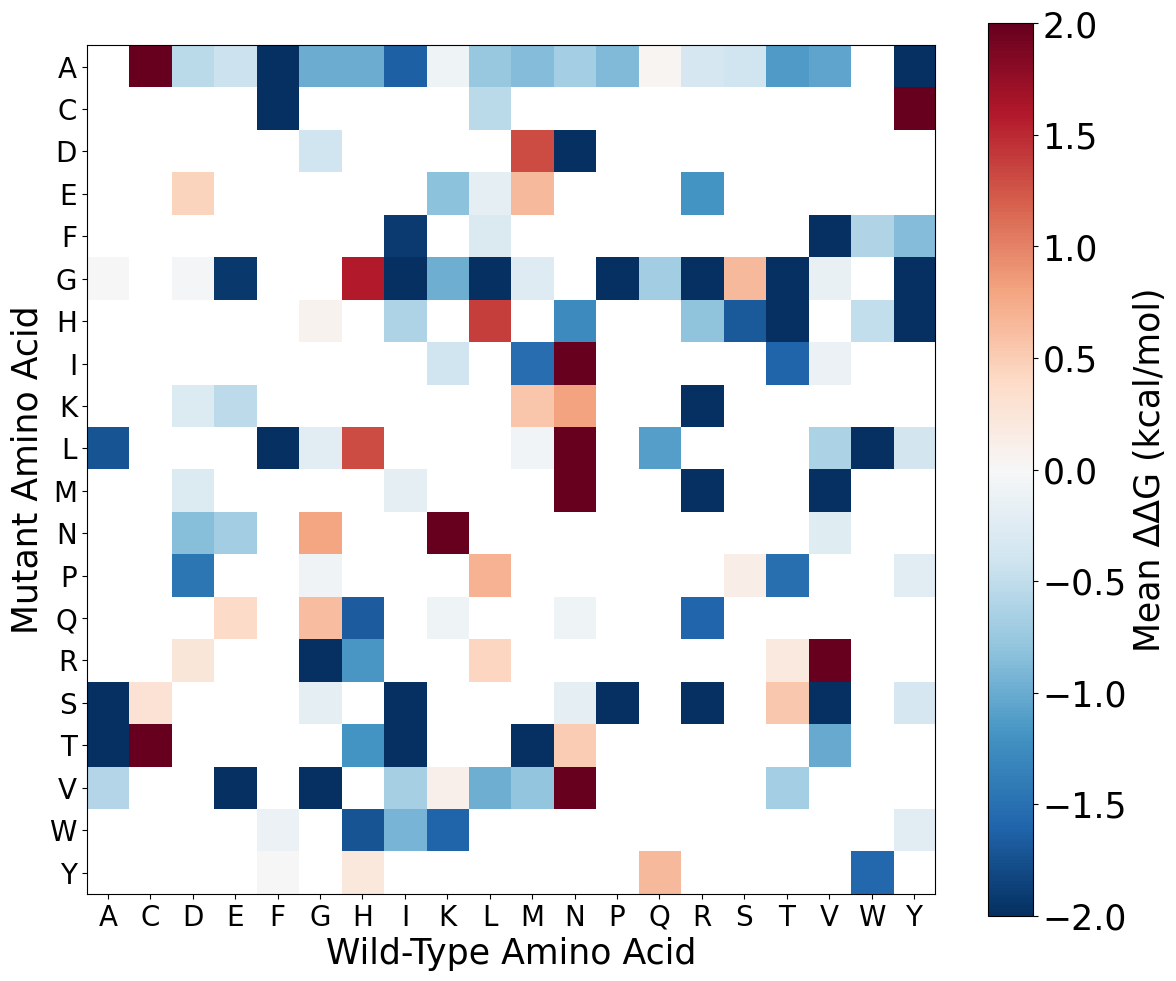

In [27]:
# mutation substitution heatmap
amino_acids = sorted(set(table_uniprot_xgb['WT_AA']).union(set(table_uniprot_xgb['MUT_AA'])))
matrix = pd.DataFrame(index=amino_acids, columns=amino_acids, dtype=float)

for mut in amino_acids:
    for wt in amino_acids:
        subset = table_uniprot_xgb[(table_uniprot_xgb['WT_AA'] == wt) & (table_uniprot_xgb['MUT_AA'] == mut)]['∆∆G_(kcal/mol)']
        matrix.loc[mut, wt] = subset.mean() if len(subset) > 0 else np.nan

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(matrix.values.astype(float), cmap='RdBu_r', vmin=-2, vmax=2)

ax.set_xticks(range(len(amino_acids)))
ax.set_yticks(range(len(amino_acids)))
ax.set_xticklabels(amino_acids, fontsize=20)
ax.set_yticklabels(amino_acids, fontsize=20)

ax.set_xlabel('Wild-Type Amino Acid', fontsize=25)
ax.set_ylabel('Mutant Amino Acid', fontsize=25)
# ax.set_title('Mean ΔΔG by Substitution Type (WT → Mutant)', fontsize=18)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean ΔΔG (kcal/mol)', fontsize=25)
cbar.ax.tick_params(labelsize=25)

plt.tight_layout()
plt.show()

C:\Users\amyac\AppData\Local\Temp\ipykernel_35836\3628149761.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=13)


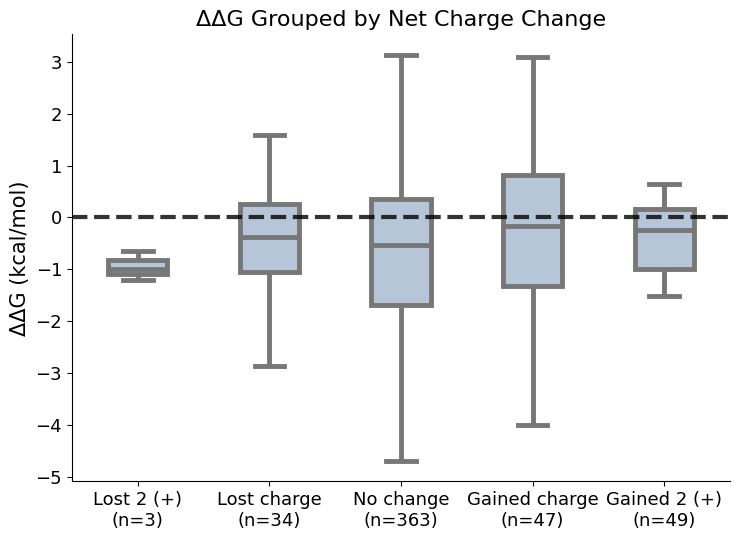

In [28]:
# charge change
charge_labels = {-2: 'Lost 2 (+)', -1: 'Lost charge', 0: 'No change', 1: 'Gained charge', 2: 'Gained 2 (+)'}
charge_order = [-2, -1, 0, 1, 2]

plot_df = table_uniprot_xgb[['delta_charge', '∆∆G_(kcal/mol)']].copy()
plot_df = plot_df[plot_df['delta_charge'].isin(charge_order)].copy()

counts = plot_df['delta_charge'].value_counts().reindex(charge_order)
tick_labels = [f"{charge_labels[k]}\n(n={counts[k]})" for k in charge_order]

plot_df['Charge Category'] = pd.Categorical(plot_df['delta_charge'], categories=charge_order, ordered=True)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

sns.boxplot(data=plot_df, x='Charge Category', y='∆∆G_(kcal/mol)', order=charge_order, width=0.45, showfliers=False, ax=ax, color='lightsteelblue', linewidth=3.5)
# sns.stripplot(data=plot_df, x='Charge Category', y='∆∆G_(kcal/mol)', order=charge_order, ax=ax, color='navy', alpha=0.75, size=6, jitter=0)

ax.axhline(0, color='black', linestyle='--', linewidth=3, alpha=0.8)

ax.set_xticklabels(tick_labels, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('ΔΔG (kcal/mol)', fontsize=15)
ax.set_title('ΔΔG Grouped by Net Charge Change', fontsize=16)
ax.tick_params(axis='y', labelsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

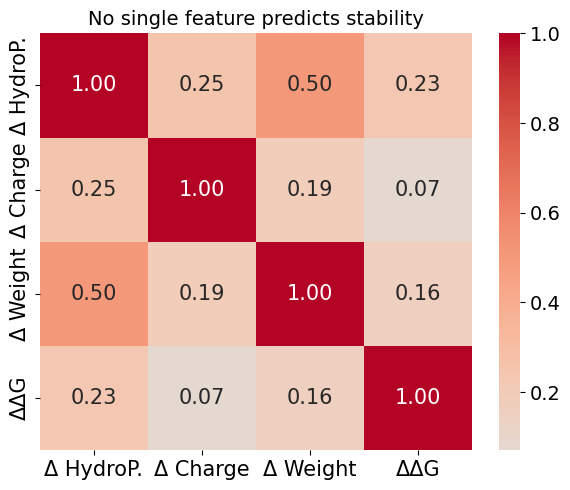

In [29]:
#to show no single feature correlates strongly with ddG in isolation --> motivates us using a model that captures interactions
features = ['delta_hydrophobicity', 'delta_charge', 'delta_weight', '∆∆G_(kcal/mol)']
corr = table_uniprot_xgb[features].corr()

fig, ax = plt.subplots(figsize=(6, 5))
hm = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 15}, xticklabels=['Δ HydroP.', 'Δ Charge', 'Δ Weight', 'ΔΔG'], yticklabels=['Δ HydroP.', 'Δ Charge', 'Δ Weight', 'ΔΔG'], ax=ax)

ax.set_title('No single feature predicts stability', fontsize=14)
ax.tick_params(axis='both', labelsize=15)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

## 3. Implement baseline model (XGBoost)

### 3.A keep only df columns that will be used by XGBoost

In [30]:
cols_to_keep = ['PROTEIN', '∆∆G_(kcal/mol)', 'delta_hydrophobicity', 'delta_charge', 'delta_weight']

one_hot_cols = [c for c in table_uniprot_xgb.columns 
                if (c.startswith('WT_') or c.startswith('MUT_')) 
                and c not in ['WT_AA', 'MUT_AA']]  # ← exclude raw string columns

cols_to_keep += one_hot_cols
df = table_uniprot_xgb[cols_to_keep].copy()
baseline_uniprot_df = df.rename(columns={'∆∆G_(kcal/mol)': 'ddG'})

print(f"dataset shape: {baseline_uniprot_df.shape}")
print(f"unique proteins: {baseline_uniprot_df['PROTEIN'].nunique()}")

dataset shape: (496, 45)
unique proteins: 46


### 3.B split into train/val/test


#### per-mutation split (for each protein, distribute its mutations 60/20/20 across train/val/test)

In [31]:
def per_protein_split(baseline_uniprot_df, train_frac=0.6, val_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []

    for protein, group in df.groupby('PROTEIN'):
        idx = group.index.tolist()
        rng.shuffle(idx)
        n = len(idx)
        n_train = max(1, int(np.floor(train_frac * n)))
        n_val   = max(1, int(np.floor(val_frac * n)))
        # remaining go to test (at least 1 if possible)
        train_idx += idx[:n_train]
        val_idx   += idx[n_train:n_train + n_val]
        test_idx  += idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = per_protein_split(df)

train_df = df.loc[train_idx]
val_df   = df.loc[val_idx]
test_df  = df.loc[test_idx]

print(f"\nPer-mutation split:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"  Val:   {len(val_df)}   ({len(val_df)/len(df):.1%})")
print(f"  Test:  {len(test_df)}  ({len(test_df)/len(df):.1%})")


Per-mutation split:
  Train: 282 (56.9%)
  Val:   95   (19.2%)
  Test:  119  (24.0%)


In [32]:
train_df.columns

Index(['PROTEIN', '∆∆G_(kcal/mol)', 'delta_hydrophobicity', 'delta_charge',
       'delta_weight', 'WT_A', 'WT_C', 'WT_D', 'WT_E', 'WT_F', 'WT_G', 'WT_H',
       'WT_I', 'WT_K', 'WT_L', 'WT_M', 'WT_N', 'WT_P', 'WT_Q', 'WT_R', 'WT_S',
       'WT_T', 'WT_V', 'WT_W', 'WT_Y', 'MUT_A', 'MUT_C', 'MUT_D', 'MUT_E',
       'MUT_F', 'MUT_G', 'MUT_H', 'MUT_I', 'MUT_K', 'MUT_L', 'MUT_M', 'MUT_N',
       'MUT_P', 'MUT_Q', 'MUT_R', 'MUT_S', 'MUT_T', 'MUT_V', 'MUT_W', 'MUT_Y'],
      dtype='str')

#### protein level split (entire proteins assigned to one split only; to test unseeen proteins)

In [33]:
def protein_level_split(baseline_uniprot_df, train_frac=0.6, val_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    proteins = df['PROTEIN'].unique().tolist()
    rng.shuffle(proteins)
    
    n = len(proteins)
    n_train = int(np.floor(train_frac * n))
    n_val   = int(np.floor(val_frac * n))

    train_proteins = set(proteins[:n_train])
    val_proteins   = set(proteins[n_train:n_train + n_val])
    test_proteins  = set(proteins[n_train + n_val:])

    return (
        df[df['PROTEIN'].isin(train_proteins)],
        df[df['PROTEIN'].isin(val_proteins)],
        df[df['PROTEIN'].isin(test_proteins)]
    )

train_prot, val_prot, test_prot = protein_level_split(df)

print(f"\nProtein-level split:")
print(f"  Train: {len(train_prot)} mutations, {train_prot['PROTEIN'].nunique()} proteins")
print(f"  Val:   {len(val_prot)} mutations,   {val_prot['PROTEIN'].nunique()} proteins")
print(f"  Test:  {len(test_prot)} mutations,  {test_prot['PROTEIN'].nunique()} proteins")



Protein-level split:
  Train: 275 mutations, 27 proteins
  Val:   123 mutations,   9 proteins
  Test:  98 mutations,  10 proteins


### 3.C data splits

In [34]:
feature_cols = [c for c in baseline_uniprot_df.columns if c not in ['PROTEIN', 'ddG']]

X_train = train_df[feature_cols].values
y_train = train_df['∆∆G_(kcal/mol)'].values

X_val   = val_df[feature_cols].values
y_val   = val_df['∆∆G_(kcal/mol)'].values

X_test  = test_df[feature_cols].values
y_test  = test_df['∆∆G_(kcal/mol)'].values

print(f"Features used: {feature_cols}")
print(f"X_train shape: {X_train.shape}")


Features used: ['delta_hydrophobicity', 'delta_charge', 'delta_weight', 'WT_A', 'WT_C', 'WT_D', 'WT_E', 'WT_F', 'WT_G', 'WT_H', 'WT_I', 'WT_K', 'WT_L', 'WT_M', 'WT_N', 'WT_P', 'WT_Q', 'WT_R', 'WT_S', 'WT_T', 'WT_V', 'WT_W', 'WT_Y', 'MUT_A', 'MUT_C', 'MUT_D', 'MUT_E', 'MUT_F', 'MUT_G', 'MUT_H', 'MUT_I', 'MUT_K', 'MUT_L', 'MUT_M', 'MUT_N', 'MUT_P', 'MUT_Q', 'MUT_R', 'MUT_S', 'MUT_T', 'MUT_V', 'MUT_W', 'MUT_Y']
X_train shape: (282, 43)


### 3.D train XGBoost

In [35]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

In [36]:
model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='rmse', early_stopping_rounds=20,)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

[0]	validation_0-rmse:1.78026
[50]	validation_0-rmse:1.61752
[67]	validation_0-rmse:1.62202


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [37]:
# run both types: 
### Hyperparameter sensitivity (val only — for model selection)
from itertools import product

configs = [
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 4, 'learning_rate': 0.01, 'n_estimators': 300},
    {'max_depth': 4, 'learning_rate': 0.10, 'n_estimators': 300},
]

print("── Hyperparameter Search (Val only) ─────────────────")
print(f"{'depth':>6} {'lr':>6} | {'Val r':>8} {'Val RMSE':>10}")
print("-" * 40)

best_val_r = -np.inf
best_cfg = None

for cfg in configs:
    m = XGBRegressor(**cfg, subsample=0.8, colsample_bytree=0.8,
                     random_state=42, eval_metric='rmse',
                     early_stopping_rounds=20)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    val_preds = m.predict(X_val)
    val_r, _  = pearsonr(y_val, val_preds)
    val_rmse  = np.sqrt(mean_squared_error(y_val, val_preds))
    
    print(f"  {cfg['max_depth']:>4} {cfg['learning_rate']:>6} | {val_r:>8.3f} {val_rmse:>10.3f}")
    
    if val_r > best_val_r:
        best_val_r = val_r
        best_cfg = cfg

print(f"\n→ Best config: {best_cfg}")

### Final evaluation with best config — both splits
print("\n── Final Evaluation ─────────────────────────────────")
print(f"{'Split Type':>20} {'Set':>6} | {'Pearson r':>10} {'RMSE':>10}")
print("-" * 55)

splits = {
    'Per-Mutation': (X_train, y_train, X_val, y_val, X_test, y_test),
    'Protein-Level': (
        train_prot[feature_cols].values, train_prot['∆∆G_(kcal/mol)'].values,
        val_prot[feature_cols].values,   val_prot['∆∆G_(kcal/mol)'].values,
        test_prot[feature_cols].values,  test_prot['∆∆G_(kcal/mol)'].values,
    )
}

for split_name, (Xtr, ytr, Xv, yv, Xt, yt) in splits.items():
    final_model = XGBRegressor(
        **best_cfg, subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='rmse', early_stopping_rounds=20
    )
    final_model.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)

    for set_name, X, y in [('Val', Xv, yv), ('Test', Xt, yt)]:
        preds = final_model.predict(X)
        r, _  = pearsonr(y, preds)
        rmse  = np.sqrt(mean_squared_error(y, preds))
        print(f"  {split_name:>20} {set_name:>6} | {r:>10.3f} {rmse:>10.3f} kcal/mol")
    print()

── Hyperparameter Search (Val only) ─────────────────
 depth     lr |    Val r   Val RMSE
----------------------------------------
     3   0.05 |    0.438      1.608
     4   0.05 |    0.432      1.613
     6   0.05 |    0.455      1.593
     4   0.01 |    0.418      1.623
     4    0.1 |    0.415      1.633

→ Best config: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300}

── Final Evaluation ─────────────────────────────────
          Split Type    Set |  Pearson r       RMSE
-------------------------------------------------------
          Per-Mutation    Val |      0.455      1.593 kcal/mol
          Per-Mutation   Test |      0.403      1.799 kcal/mol

         Protein-Level    Val |      0.060      3.153 kcal/mol
         Protein-Level   Test |      0.207      1.807 kcal/mol



### 3.E XGBoost evaluation

In [38]:
def evaluate(model, X, y, split_name):
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r, _ = pearsonr(y, preds)
    print(f"{split_name:10s} | Pearson r: {r:.3f} | RMSE: {rmse:.3f} kcal/mol")
    return preds, r, rmse

print("── Results ──────────────────────────────")
_, _, _  = evaluate(model, X_train, y_train, "Train")
_, _, _  = evaluate(model, X_val,   y_val,   "Val")
test_preds, test_r, test_rmse = evaluate(model, X_test, y_test, "Test")

── Results ──────────────────────────────
Train      | Pearson r: 0.720 | RMSE: 1.560 kcal/mol
Val        | Pearson r: 0.432 | RMSE: 1.613 kcal/mol
Test       | Pearson r: 0.420 | RMSE: 1.772 kcal/mol


### 3.F plots

#### per mutation and protein level split 

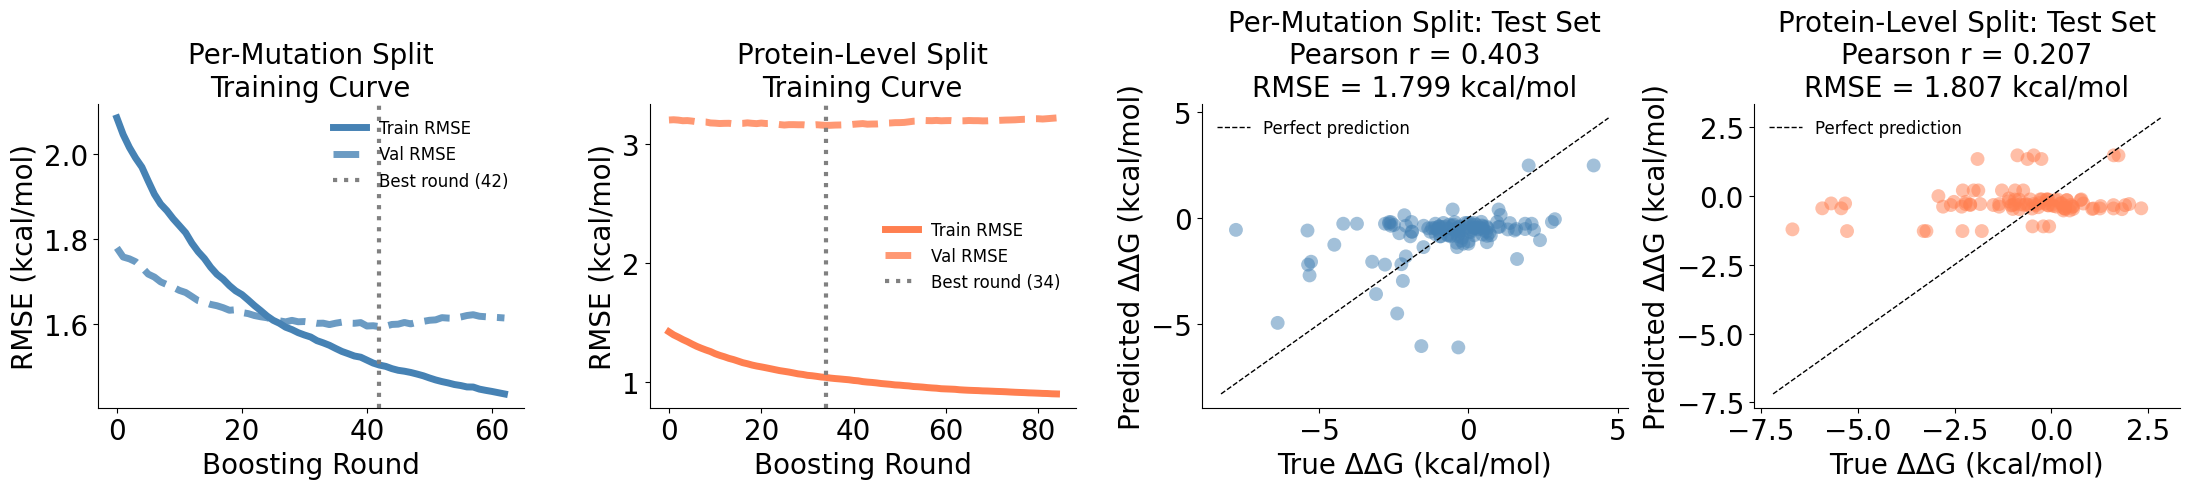

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

split_configs = {
    'Per-Mutation': (X_train, y_train, X_val, y_val, X_test, y_test, 20),
    'Protein-Level': (
        train_prot[feature_cols].values, train_prot['∆∆G_(kcal/mol)'].values,
        val_prot[feature_cols].values,   val_prot['∆∆G_(kcal/mol)'].values,
        test_prot[feature_cols].values,  test_prot['∆∆G_(kcal/mol)'].values,
        50  # more patience for protein-level since val set is small
    )
}

colors = {'Per-Mutation': 'steelblue', 'Protein-Level': 'coral'}
curves = {}
final_preds = {}

for split_name, (*data, patience) in split_configs.items():
    Xtr, ytr, Xv, yv, Xt, yt = data
    m = XGBRegressor(
        **best_cfg, subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='rmse',
        early_stopping_rounds=patience
    )
    m.fit(Xtr, ytr, eval_set=[(Xtr, ytr), (Xv, yv)], verbose=False)
    results = m.evals_result()
    curves[split_name] = {
        'train': results['validation_0']['rmse'],
        'val':   results['validation_1']['rmse'],
        'best':  m.best_iteration
    }
    preds = m.predict(Xt)
    final_preds[split_name] = {
        'test_preds': preds,
        'y_test': yt,
        'r':    pearsonr(yt, preds)[0],
        'rmse': np.sqrt(mean_squared_error(yt, preds))
    }

# ── Panel A: Per-Mutation training curve ──────────────────────
for i, (split_name, col) in enumerate(colors.items()):
    ax = axes[i]
    c = curves[split_name]
    ax.plot(c['train'], color=col, linestyle='-',
            label='Train RMSE', linewidth=5)
    ax.plot(c['val'],   color=col, linestyle='--',
            label='Val RMSE',   linewidth=5, alpha=0.8)
    ax.axvline(c['best'], color='gray', linestyle=':',
               linewidth=3, label=f'Best round ({c["best"]})')
    ax.set_xlabel('Boosting Round', fontsize=20)
    ax.set_ylabel('RMSE (kcal/mol)', fontsize=20)
    ax.set_title(f'{split_name} Split\nTraining Curve', fontsize=20)
    ax.legend(fontsize=12, frameon=False)
    ax.tick_params(axis='both', labelsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Panels C & D: Predicted vs actual ─────────────────────────
for i, (split_name, col) in enumerate(colors.items()):
    ax = axes[i + 2]
    d = final_preds[split_name]
    ax.scatter(d['y_test'], d['test_preds'],
               alpha=0.5, s=100, color=col, edgecolors='none')
    lims = [min(d['y_test'].min(), d['test_preds'].min()) - 0.5,
            max(d['y_test'].max(), d['test_preds'].max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('True ΔΔG (kcal/mol)', fontsize=20)
    ax.set_ylabel('Predicted ΔΔG (kcal/mol)', fontsize=20)
    ax.set_title(f'{split_name} Split: Test Set\n'
                 f'Pearson r = {d["r"]:.3f}\n'
                 f'RMSE = {d["rmse"]:.3f} kcal/mol', fontsize=20)
    ax.legend(fontsize=12, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='both', labelsize=20)
    ax.spines['right'].set_visible(False)

# plt.suptitle('XGBoost Baseline: Training Dynamics and Test Performance',
#              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. (GNN) Map each entry to AlphaFold using UniProt/PDB IDs

Get WT and mutant structures for each protein. WT structures can be directly obtained from PDB/UniProt IDs. For the mutations that have their own PDB structures, we can use those directly. For the others, we have a UniProt ID and a specific mutation, and we can use AlphaFold to make a prediction for what the mutant structure will be.

## 5. (GNN) Build residue contact graph

The `graphein` library can take a PDB or AlphaFold structure and automatically generate a graph. Our next task will be to assign the correct features to each node and figure out how this library integrates with AlphaFold. We will also need to learn how to use AlphaFold to predict mutant structures rather than simply pulling from their database.

In [40]:
# ! pip install graphein

In [41]:
from graphein.protein.config import ProteinGraphConfig
from graphein.protein.graphs import construct_graph
from graphein.protein.utils import download_alphafold_structure

config = ProteinGraphConfig()
# fp = download_alphafold_structure("Q5VSL9", aligned_score=False)
g = construct_graph(config=config, pdb_code='3eiy')

C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\amyac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

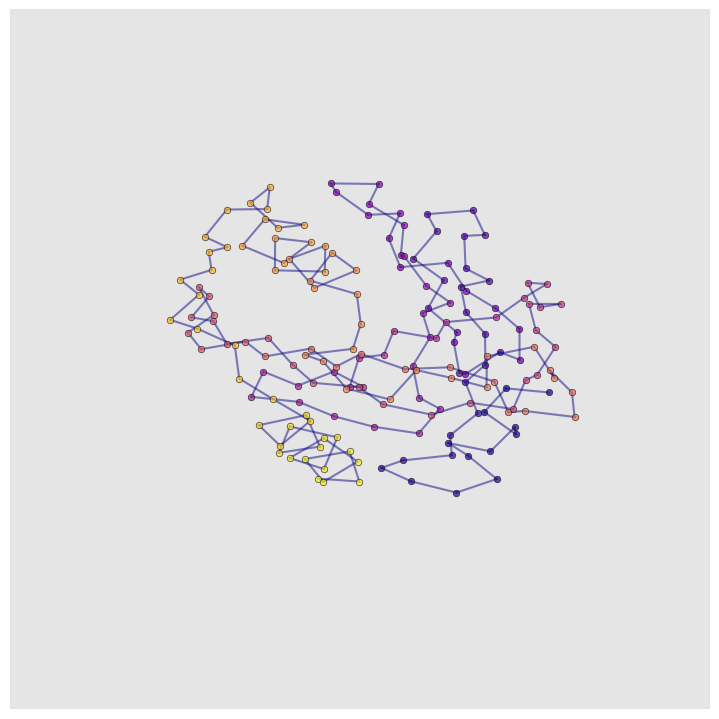

In [42]:
from graphein.protein.visualisation import plot_protein_structure_graph

# example of what the graph could look like
p = plot_protein_structure_graph(G=g, angle=0, colour_edges_by="kind", colour_nodes_by="seq_position", label_node_ids=False)

In [43]:
# TODO (for GNN):
# - download all pdbs for WT structures and PDB mutants
#   - can use requests/urllib to download all pdbs if we need the files
# - look into alphafold's api for predicting structures for UniProt mutants
# - from what i've read, i believe alphafold returns a .pdb file as well?
# - next issue will be parsing pdb files and turning them into graphs
# - graphein to create graphs? BioPython and ProDy both have pdb parsers (probably just use graphein)?